# 1. Install Dependencies and Setup

In [ ]:
!pip list

In [1]:
import tensorflow as tf
import os

In [2]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# 2. Remove dodgy images

In [3]:
import cv2
import imghdr

In [4]:
data_dir = 'data' 

In [5]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [6]:
for image_class in os.listdir(data_dir): 
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try: 
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts: 
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e: 
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# 3. Load Data

In [7]:
import numpy as np
from matplotlib import pyplot as plt

In [8]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 1317 files belonging to 7 classes.


In [9]:
data_iterator = data.as_numpy_iterator()

In [10]:
batch = data_iterator.next()

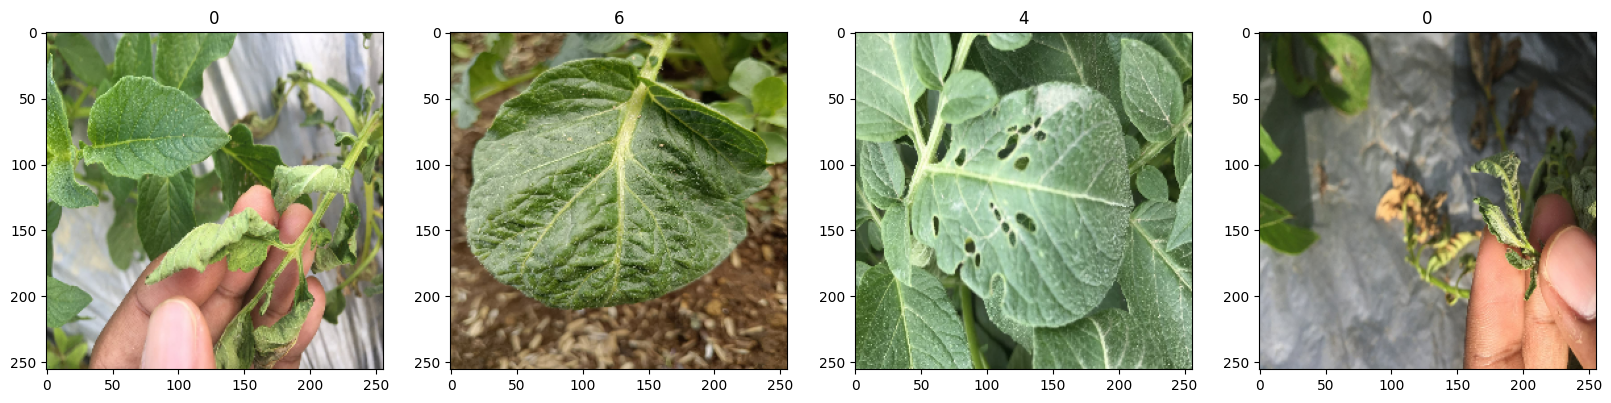

In [11]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 4. Scale Data

In [12]:
data = data.map(lambda x,y: (x/255, y))

In [13]:
data.as_numpy_iterator().next()

(array([[[[0.45772058, 0.6045037 , 0.3230167 ],
          [0.5036032 , 0.6408581 , 0.37419146],
          [0.36739144, 0.4866929 , 0.23282757],
          ...,
          [0.41400123, 0.5512561 , 0.19047181],
          [0.41568628, 0.5529412 , 0.18431373],
          [0.41289827, 0.5501532 , 0.18152574]],
 
         [[0.52857834, 0.6736764 , 0.36510107],
          [0.5083714 , 0.62569076, 0.38708782],
          [0.09124804, 0.19320883, 0.01405819],
          ...,
          [0.4117647 , 0.54901963, 0.1882353 ],
          [0.41568628, 0.5529412 , 0.18431373],
          [0.43694854, 0.57420343, 0.20557599]],
 
         [[0.50774765, 0.62114114, 0.39706025],
          [0.0912703 , 0.19264898, 0.01792471],
          [0.11534472, 0.195436  , 0.05436557],
          ...,
          [0.41960785, 0.5568628 , 0.19607843],
          [0.42369768, 0.56078434, 0.19215687],
          [0.43946582, 0.5764706 , 0.20784314]],
 
         ...,
 
         [[0.11101936, 0.1933723 , 0.04043112],
          [0.13033

# 5. Split Data

In [14]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [15]:
train_size

29

In [16]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

# 6. Build Deep Learning Model

In [17]:
train

<TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [121]:
import os
import tensorflow as tf
import numpy as np

# 1. OPTIONAL: Hide extra system warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 2. GPU Memory Growth Fix (Prevents crashes on modern GPUs)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Successfully found GPU and set memory growth.")
    except RuntimeError as e:
        print(f"GPU Error: {e}")

# 3. Load Dataset
# Note: Ensure your 'data' folder has 7 subfolders for this specific code.
data = tf.keras.utils.image_dataset_from_directory(
    'data',
    image_size=(256, 256),
    batch_size=32,
    label_mode='int' # This produces integers (0, 1, 2...) for SparseCategoricalCrossentropy
)

# Scale images from [0, 255] to [0, 1]
data = data.map(lambda x, y: (x / 255.0, y))

# Split data (80% train, 20% validation)
train_size = int(len(data) * 0.8)
train = data.take(train_size)
val = data.skip(train_size)

# 4. Build Model (Transfer Learning with MobileNetV2)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2

def create_transfer_learning_model():
    # include_top=False removes the final classification layer of MobileNet
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(256, 256, 3))
    base_model.trainable = False  # Freeze the pre-trained weights

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(7, activation='softmax') # Match this '7' to your folder count
    ])
    return model

model = create_transfer_learning_model()

# 5. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy', # Used because labels are integers
    metrics=['accuracy']
)

# 6. Train
# If it hangs at the start of Epoch 1, remember it's just JIT-compiling for your GPU!
print("Starting training...")
hist = model.fit(
    train,
    epochs=20,
    validation_data=val
)

# 7. Verification
print("\nTraining Complete!")

GPU Error: Physical devices cannot be modified after being initialized
Found 1317 files belonging to 7 classes.
Starting training...
Epoch 1/20
33/33 [==============================] - 12s 267ms/step - loss: 1.5850 - accuracy: 0.3996 - val_loss: 1.0763 - val_accuracy: 0.6322
Epoch 2/20
33/33 [==============================] - 9s 241ms/step - loss: 1.1067 - accuracy: 0.6061 - val_loss: 0.8351 - val_accuracy: 0.6973
Epoch 3/20
33/33 [==============================] - 8s 240ms/step - loss: 0.8990 - accuracy: 0.6875 - val_loss: 0.7144 - val_accuracy: 0.7816
Epoch 4/20
33/33 [==============================] - 7s 186ms/step - loss: 0.8223 - accuracy: 0.7102 - val_loss: 0.5942 - val_accuracy: 0.8199
Epoch 5/20
33/33 [==============================] - 9s 241ms/step - loss: 0.6972 - accuracy: 0.7633 - val_loss: 0.5005 - val_accuracy: 0.8544
Epoch 6/20
33/33 [==============================] - 9s 243ms/step - loss: 0.6020 - accuracy: 0.7841 - val_loss: 0.5271 - val_accuracy: 0.8391
Epoch 7/20
33/

In [122]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [123]:
model.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 8, 8, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_7   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_14 (Dense)            (None, 128)               163968    
                                                                 
 dropout_7 (Dropout)         (None, 128)               0         
                                                                 
 dense_15 (Dense)            (None, 7)                 903       
                                                                 
Total params: 2,422,855
Trainable params: 164,871
Non

# 7. Train

In [124]:
logdir='logs'

In [125]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

# 8. Plot Performance

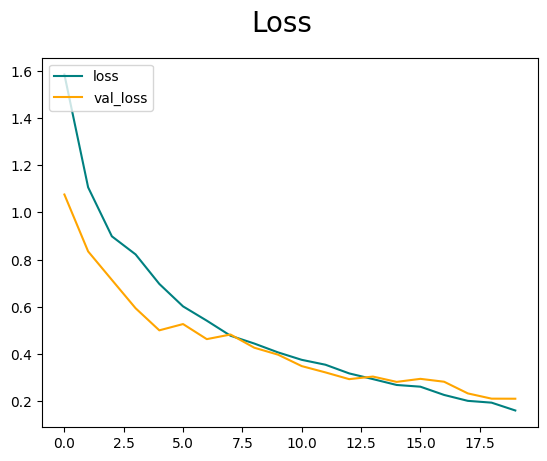

In [126]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

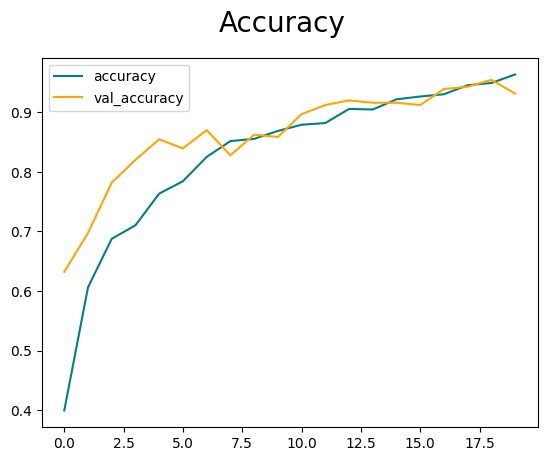

In [127]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [128]:
model.save('potato.h5')
print("Model saved as potato_leaf.h5")

Model saved as potato_leaf.h5


In [129]:
from tensorflow.keras.models import load_model
model = load_model("potato.h5")

# 9. Evaluate

In [130]:
print(model)

In [131]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for X, y in test:
    preds = model.predict(X)
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))
print(confusion_matrix(y_true, y_pred))

1/1 [==============================] - 0s 20ms/step
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.94      0.97        17
           2       1.00      1.00      1.00        14
           3       1.00      0.86      0.92         7
           4       0.95      1.00      0.97        36
           5       0.95      1.00      0.97        19
           6       1.00      0.90      0.95        21

    accuracy                           0.97       128
   macro avg       0.98      0.96      0.97       128
weighted avg       0.97      0.97      0.97       128

[[14  0  0  0  0  0  0]
 [ 0 16  0  0  1  0  0]
 [ 0  0 14  0  0  0  0]
 [ 1  0  0  6  0  0  0]
 [ 0  0  0  0 36  0  0]
 [ 0  0  0  0  0 19  0]
 [ 0  0  0  0  1  1 19]]


In [132]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.0, shape=(), dtype=float32)


# 10. Test

In [133]:
import cv2

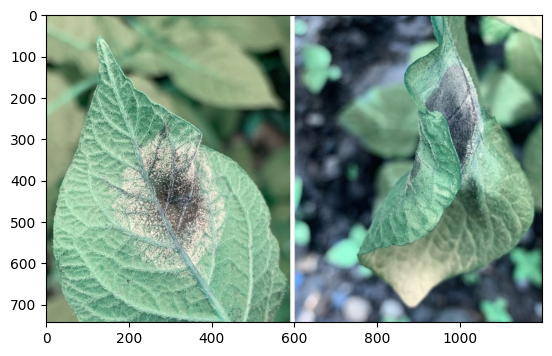

In [139]:
img = cv2.imread('d.jpg')
plt.imshow(img)
plt.show()

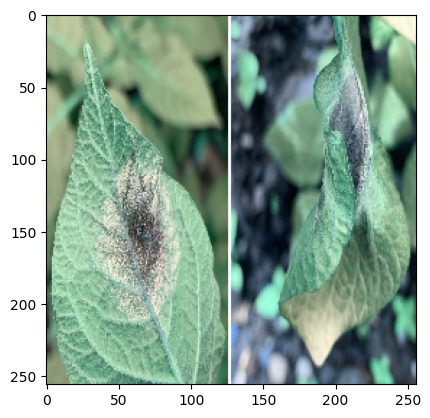

In [140]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [141]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 0s 29ms/step


In [142]:
yhat

array([[4.1667369e-04, 4.4981563e-03, 1.1845448e-03, 3.6810200e-06,
        1.2671870e-02, 8.9914834e-01, 8.2076870e-02]], dtype=float32)

In [143]:
# yhat = model.predict(single_image)  # shape: (1, 7)
predicted_class = np.argmax(yhat, axis=1)[0]  # pick the index of the highest probability

# Optionally, map to human-readable labels
class_names = ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']

print(f'Predicted class is {class_names[predicted_class]}')

Predicted class is Phytopthora
